In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fintech_sales_raw.csv to fintech_sales_raw.csv
Saving monthly_targets.csv to monthly_targets.csv


In [ ]:
import pandas as pd

sales = pd.read_csv("fintech_sales_raw.csv")
targets = pd.read_csv("monthly_targets.csv")

print(sales.shape)
print(sales.info())
print(sales.describe())
print(sales.isnull().sum())
sales.head()

(1260, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1260 non-null   object 
 1   Year              1260 non-null   int64  
 2   Month             1260 non-null   int64  
 3   Region            1260 non-null   object 
 4   Product           1260 non-null   object 
 5   Channel           1260 non-null   object 
 6   Customer_Segment  1260 non-null   object 
 7   Units_Sold        1260 non-null   int64  
 8   Revenue_USD       1260 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 88.7+ KB
None
              Year        Month   Units_Sold    Revenue_USD
count  1260.000000  1260.000000  1260.000000    1260.000000
mean   2024.000000     6.500000   349.560317   64903.426024
std       0.816821     3.453423   361.293089   26688.346463
min    2023.000000     1.000000     6.000000   18289.390000

,Date,Year,Month,Region,Product,Channel,Customer_Segment,Units_Sold,Revenue_USD
0,2023-01-01,2023,1,North America,Personal Loan,Branch (Assisted),SME,548,77979.06
1,2023-02-01,2023,2,North America,Personal Loan,Mobile App,Retail,457,66270.48
2,2023-03-01,2023,3,North America,Personal Loan,Mobile App,Retail,667,99038.09
3,2023-04-01,2023,4,North America,Personal Loan,Mobile App,Retail,649,93121.20
4,2023-05-01,2023,5,North America,Personal Loan,Mobile App,SME,527,76793.65


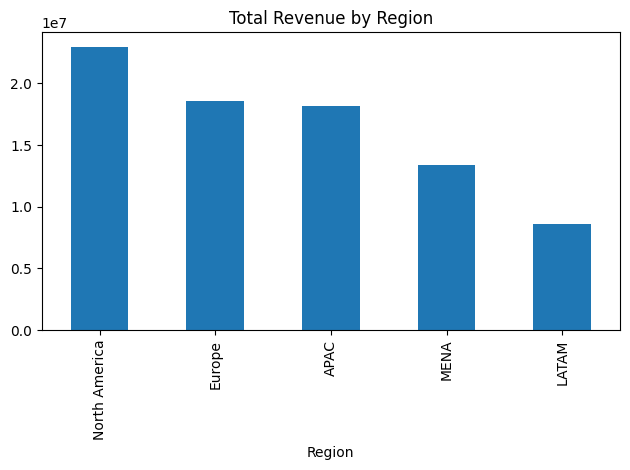

In [ ]:
import matplotlib.pyplot as plt

sales.groupby("Region")["Revenue_USD"].sum().sort_values(ascending=False).plot(kind="bar", title="Total Revenue by Region")
plt.tight_layout()
plt.show()

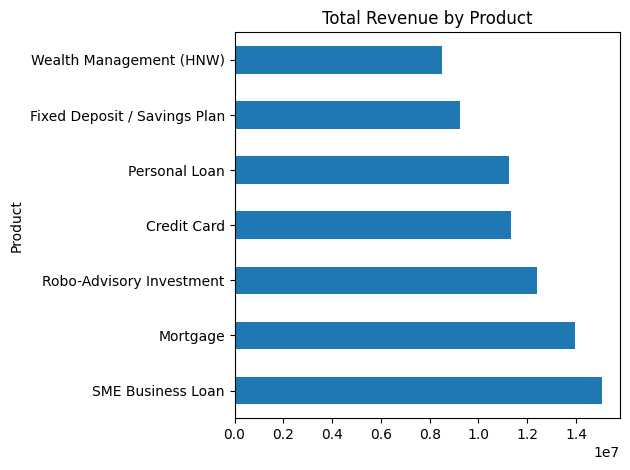

In [ ]:
sales.groupby("Product")["Revenue_USD"].sum().sort_values(ascending=False).plot(kind="barh", title="Total Revenue by Product")
plt.tight_layout()
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect(":memory:")
sales.to_sql("sales", conn, index=False)
targets.to_sql("targets", conn, index=False)

180

In [ ]:
q1 = """
SELECT Product, ROUND(SUM(Revenue_USD),0) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
pd.read_sql(q1, conn)

,Product,Total_Revenue
0,SME Business Loan,15049649.0
1,Mortgage,13974105.0
2,Robo-Advisory Investment,12393937.0
3,Credit Card,11331971.0
4,Personal Loan,11270945.0


In [ ]:
q2 = """
SELECT Product, ROUND(SUM(Revenue_USD),0) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue ASC
LIMIT 5;
"""
pd.read_sql(q2, conn)

,Product,Total_Revenue
0,Wealth Management (HNW),8516261.0
1,Fixed Deposit / Savings Plan,9241448.0
2,Personal Loan,11270945.0
3,Credit Card,11331971.0
4,Robo-Advisory Investment,12393937.0


In [ ]:
q3 = """
WITH yearly AS (
  SELECT Region, Year, SUM(Revenue_USD) AS Revenue
  FROM sales
  WHERE Year IN (2023, 2025)
  GROUP BY Region, Year
)
SELECT
  y23.Region,
  ROUND(y23.Revenue,0) AS Revenue_2023,
  ROUND(y25.Revenue,0) AS Revenue_2025,
  ROUND(((y25.Revenue - y23.Revenue) / y23.Revenue) * 100, 1) AS Growth_Pct
FROM yearly y23
JOIN yearly y25 ON y23.Region = y25.Region AND y23.Year = 2023 AND y25.Year = 2025
ORDER BY Growth_Pct DESC;
"""
pd.read_sql(q3, conn)

,Region,Revenue_2023,Revenue_2025,Growth_Pct
0,MENA,3411325.0,5539906.0,62.4
1,APAC,5058416.0,7172077.0,41.8
2,North America,6571338.0,8762804.0,33.3
3,LATAM,2610462.0,3141332.0,20.3
4,Europe,5664246.0,6716261.0,18.6


In [ ]:
q4 = """
SELECT
  s.Date,
  s.Region,
  ROUND(SUM(s.Revenue_USD),0) AS Actual_Revenue,
  ROUND(t.Revenue_Target_USD,0) AS Target_Revenue,
  ROUND(((SUM(s.Revenue_USD) - t.Revenue_Target_USD) / t.Revenue_Target_USD) * 100, 1) AS Pct_Vs_Target
FROM sales s
JOIN targets t ON s.Date = t.Date AND s.Region = t.Region
GROUP BY s.Date, s.Region
ORDER BY s.Date;
"""
pd.read_sql(q4, conn)

,Date,Region,Actual_Revenue,Target_Revenue,Pct_Vs_Target
0,2023-01-01,APAC,370558.0,328047.0,13.0
1,2023-01-01,Europe,439649.0,454453.0,-3.3
2,2023-01-01,LATAM,213348.0,215076.0,-0.8
3,2023-01-01,MENA,238460.0,216312.0,10.2
4,2023-01-01,North America,499253.0,497111.0,0.4
...,...,...,...,...,...
175,2025-12-01,APAC,666868.0,657078.0,1.5
176,2025-12-01,Europe,571108.0,540555.0,5.7
177,2025-12-01,LATAM,278246.0,280065.0,-0.6
178,2025-12-01,MENA,513080.0,477518.0,7.4
